In [31]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load model safely with weights_only=True
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 1000)

# Fix: Load with weights_only=True for security
model.load_state_dict(
    torch.load('work_type_classification_model.pth', 
               map_location=torch.device('cpu'),  # Add device if needed
               weights_only=True)  # Critical security fix
)
model.eval()

# Create new model properly
new_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
new_model.fc = nn.Linear(new_model.fc.in_features, 2)

# Fix: Use proper weight/bias copying
with torch.no_grad():
    new_model.fc.weight.data.copy_(model.fc.weight.data[:2])  # First 2 classes
    new_model.fc.bias.data.copy_(model.fc.bias.data[:2])

In [33]:
image_path = 'dataset/test_image/test.jpg'

image = Image.open(image_path)
preprocess = transforms.Compose([
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
input_tensor = preprocess(image)
input_batch = input_tensor.unsqueeze(0) # Add a batch dimension

In [35]:
#perform inference
with torch.no_grad():
    output = model(input_batch)

#Get the predicted class
_, predicted_class = output.max(1)

#Map the predicted class to the class name
class_names = ['prints','sculptures'] #Make sure these class names match your training data
predicted_class_name = class_names[predicted_class.item()]

print(f'This Images belongs to the class {predicted_class_name}')

This Images belongs to the class sculptures


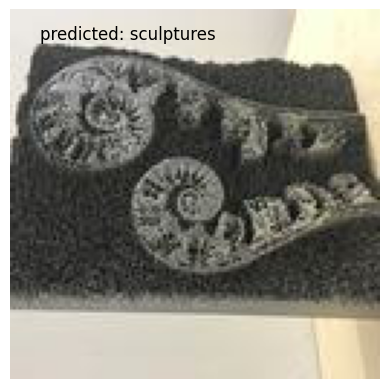

In [37]:
%matplotlib inline

image = np.array(image)
plt.imshow(image)
plt.axis('off')
plt.text(10,10, f'predicted: {predicted_class_name}', fontsize=12,color='black')
plt.show()